## RAG in langgraph

In [1]:
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from dotenv import load_dotenv
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START
from typing import Annotated, TypedDict
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, BaseMessage
from langgraph.prebuilt import ToolNode, tools_condition

/var/folders/nz/l_5d98c53hsgs16yvxmvz5q40000gn/T/ipykernel_10847/2220308210.py:3: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


In [2]:
load_dotenv()

True

In [3]:
model = ChatOpenAI(model = "gpt-5.4-mini-2026-03-17" , temperature = 0)
# model = ChatOpenAI(
#     model="openai/gpt-5.4-mini",
#     api_key=os.getenv("OPENROUTER_API_KEY"),
#     base_url="https://openrouter.ai/api/v1",
#     temperature=0,
# )

In [4]:
loader = PyPDFLoader("../data/intro-to-ml.pdf")
docs = loader.load()

In [5]:
len(docs)

674

In [6]:
splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
chunks = splitter.split_documents(docs)

In [7]:
len(chunks)

1602

In [8]:
embeddings = OpenAIEmbeddings(model='text-embedding-3-small')
vector_store = FAISS.from_documents(chunks, embeddings)

In [9]:
vector_store

In [10]:
retriever = vector_store.as_retriever(search_type='similarity', search_kwargs={'k':4})

In [11]:
retrieved_docs = retriever.invoke("What is random forest and how the root nodes are split?")

In [12]:
retrieved_docs

[Document(id='d35bc993-1528-4c25-b94a-bcbf9177ed13', metadata={'producer': 'pdfTeX-1.40.25', 'creator': 'LaTeX with hyperref', 'creationdate': '2025-05-15T00:15:19+00:00', 'author': '', 'keywords': '', 'moddate': '2025-05-15T00:15:19+00:00', 'ptex.fullbanner': 'This is pdfTeX, Version 3.141592653-2.6-1.40.25 (TeX Live 2023) kpathsea version 6.3.5', 'subject': '', 'title': '', 'trapped': '/False', 'source': '../data/intro-to-ml.pdf', 'total_pages': 674, 'page': 220, 'page_label': '221'}, page_content='Chapter 10\nTree-based Algorithms, Randomization and Boost-\ning\n10.1 Recursive Partitioning\nRecursive partitioning methods implement a “divide and conquer” strategy to ad-\ndress the prediction problem. They separate the input space RX into small regions\non which prediction is “easy,” i.e., such that the observed values of the output vari-\nable are (almost) constant for input values in these regions. The regions are esti-\nmated by recursive divisions until they become either too smal

In [13]:
for i, doc in enumerate(retrieved_docs, start=1):
    print(f"\n--- chunk {i} | page={doc.metadata.get('page')} ---\n")
    print(doc.page_content)


--- chunk 1 | page=220 ---

Chapter 10
Tree-based Algorithms, Randomization and Boost-
ing
10.1 Recursive Partitioning
Recursive partitioning methods implement a “divide and conquer” strategy to ad-
dress the prediction problem. They separate the input space RX into small regions
on which prediction is “easy,” i.e., such that the observed values of the output vari-
able are (almost) constant for input values in these regions. The regions are esti-
mated by recursive divisions until they become either too small or homogeneous.
These divisions are conveniently represented in the form of binary trees.
10.1.1 Binary prediction trees
Define a binary node to be a structureν that contains the following information (note
that the definition is recursive):
• A labelL(ν) that uniquely identifies the node.
• A set of children,C(ν), which is either empty or a pair of nodes (l(ν),r (ν)).
• A binary feature, i.e., a function γν :RX→{ 0,1}, which is “None” (i.e., irrelevant)
if the node has no child

In [14]:
@tool
def rag_tool(query):

    """
    Retrieve relevant information from the pdf document.
    Use this tool when the user asks factual / conceptual questions
    that might be answered from the stored documents.
    """
    result = retriever.invoke(query)

    context = [doc.page_content for doc in result]
    metadata = [doc.metadata for doc in result]

    return {
        'query': query,
        'context': context,
        'metadata': metadata
    }

In [15]:
tools = [rag_tool]
llm_with_tools = model.bind_tools(tools)

In [18]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [19]:
def chat_node(state: ChatState):

    messages = state['messages']

    response = llm_with_tools.invoke(messages)

    return {'messages': [response]}

In [20]:
tool_node = ToolNode(tools)

In [21]:
graph = StateGraph(ChatState)

graph.add_node('chat_node', chat_node)
graph.add_node('tools', tool_node)

graph.add_edge(START, 'chat_node')
graph.add_conditional_edges('chat_node', tools_condition)
graph.add_edge('tools', 'chat_node')

chatbot = graph.compile()

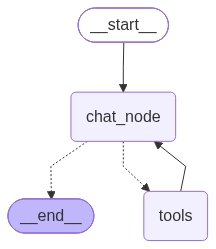

In [22]:
chatbot

In [23]:
initial_state = {
    'messages': [HumanMessage(content='What is Random Forest?')]
}

In [24]:
result = chatbot.invoke(
    initial_state
)

In [25]:
result

{'messages': [HumanMessage(content='What is Random Forest?', additional_kwargs={}, response_metadata={}, id='3e37cdfb-e63f-4060-a669-b74d71a1a1e7'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 41, 'prompt_tokens': 153, 'total_tokens': 194, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-EF8QFuQQSCKUFafFw9tuX46Lq963r', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a021f3-82ff-7c61-99dd-da2973ae8ef7-0', tool_calls=[{'name': 'rag_tool', 'args': {'query': 'What is Random Forest? Provide a concise conceptual definition, key idea, how it works, and main advantages/disadvantages.'}, 

In [26]:
print(result['messages'][-1].content)

Random Forest is an **ensemble learning method** that builds **many decision trees** and combines their outputs to make a prediction.

### Core idea
- Each tree is trained on a **random bootstrap sample** of the training data.
- At each split, the tree considers only a **random subset of features**.
- The final prediction is made by:
  - **majority vote** for classification, or
  - **averaging** for regression.

### Why it works
By randomizing both the data and the features, the trees become **less correlated**. Combining many less-correlated trees usually gives a model that is:
- more accurate than a single decision tree,
- more stable,
- less prone to overfitting.

### Main advantages
- Handles high-dimensional data well
- Works for both classification and regression
- Often strong performance with little tuning
- Robust to noise and overfitting compared with a single tree

### Main disadvantages
- Less interpretable than a single decision tree
- Can be computationally heavier
- Pred